# Credit Risk — Probability of Default (PD) Modelling

## Project Overview

This project presents an end-to-end **Probability of Default (PD)** modelling pipeline for corporate credit risk assessment. The objective is to estimate the likelihood that a company will default by combining historical customer information with expert-derived financial assessments.

The notebook follows a complete modelling workflow commonly used in credit risk analytics, including data exploration, feature engineering, Weight of Evidence (WoE) transformation, Information Value (IV)-based feature selection, statistical modelling, model validation and comparison.

Three statistical models are developed and evaluated:

* **Logistic Regression**
* **Probit Regression**
* **Linear Probability Model (LPM)**

Their performance is benchmarked against an expert-derived scorecard using industry-standard discrimination, calibration and stability metrics.

## Project Highlights

* End-to-end Probability of Default modelling workflow
* Leakage-aware data preparation and feature engineering
* Train-only WoE transformation and IV-based feature selection
* Customer-grouped, class-stratified train-test split
* Logistic, Probit and Linear Probability Model comparison
* Benchmark against an expert credit-scoring formula
* Cluster-robust inference and model stability diagnostics
* ROC, AUC, Gini, KS statistic and calibration analysis
* Bootstrap confidence intervals for model comparison
* Discussion of practical limitations and production considerations

> **Note.** This project focuses on demonstrating a statistically rigorous and reproducible PD modelling workflow rather than maximizing predictive performance. Particular emphasis is placed on preventing information leakage, validating model assumptions, and following practices commonly used in modern credit risk modelling.


## Setup

Pinned dependencies for reproducibility, imports, a global seed, and two helpers
(`run_pipeline` encapsulates the whole leakage-aware pipeline so it can be re-run per CV fold).

The code was evaluated in google colab. If you would like to run it by yourself, then firstly run the code below. After that please work with the next cell (HERE)

In [ ]:
!pip install pandas==2.2.2 numpy==1.26.4 scorecardpy==0.1.9.7 statsmodels==0.14.6 \
    scikit-learn==1.8.0 scipy==1.17.1 xlrd==2.0.2 seaborn==0.13.2 matplotlib==3.10.8 \
    tabulate==0.10.0 --break-system-packages -q

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 72.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but 

HERE - after you once ran code above, then alwats start from the code below this text

In [24]:
%matplotlib inline

import io, contextlib, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scorecardpy as sc
import statsmodels.api as sm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, balanced_accuracy_score
from scipy.stats import ks_2samp

In [25]:
# We deliberately do NOT silence warnings globally: convergence / quasi-separation messages
# from statsmodels are diagnostic here and must stay visible (see Section 6). We only filter
# library-internal FutureWarnings, which are not analysis-relevant.
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH    = "/content/credit-risk_data.xls"   # on Colab use e.g. '/content/credit-risk_data.xls'
RANDOM_STATE = 7
ID_COLS      = ["CUSTOMER_ID", "ASSESSMENT_YEAR"]   # identifiers, never predictors
RAW_FLAGS    = ["prior_default_flag"]               # entered raw (too rare to WoE-bin stably)

def _quiet(fn, *a, **k):
    # scorecardpy prints progress to stdout; silence it inside CV loops
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **k)

def find_correlated(corr, cutoff=0.75):
    # Replicates caret::findCorrelation: iteratively drop the variable with the higher mean
    # absolute correlation from the most-correlated remaining pair. (numpy-based, pandas-safe)
    a = corr.abs().where(~np.eye(len(corr), dtype=bool), np.nan)
    drop = []
    while True:
        arr = a.to_numpy()
        if np.all(np.isnan(arr)) or np.nanmax(arr) <= cutoff:
            break
        i, j = np.unravel_index(np.nanargmax(arr), arr.shape)
        c1, c2 = a.index[i], a.columns[j]
        d = c1 if np.nanmean(a[c1].to_numpy()) >= np.nanmean(a[c2].to_numpy()) else c2
        drop.append(d)
        a = a.drop(index=d, columns=d)
    return drop

def run_pipeline(train, test, return_details=False):
    '''Full leakage-aware pipeline fitted on `train`, evaluated on `test`.
    Bins, IV (from the same bins), constant/correlation pruning and the logit are all
    learned on the training set only. Returns metrics, or full objects if return_details.'''
    woe_input = [c for c in train.columns if c not in ID_COLS + RAW_FLAGS]
    tr_in, te_in = train[woe_input], test[woe_input]

    bins = _quiet(sc.woebin, tr_in, y="DEFAULT_FLAG", count_distr_limit=0.05, no_cores=1)
    # IV from the SAME binning used downstream (consistent screening)
    iv = (pd.DataFrame({"variable": list(bins),
                        "info_value": [bins[v]["total_iv"].iloc[0] for v in bins]})
            .sort_values("info_value", ascending=False).reset_index(drop=True))
    keep = iv.loc[iv["info_value"] > 0.1, "variable"].tolist()

    tr_woe = _quiet(sc.woebin_ply, tr_in[keep + ["DEFAULT_FLAG"]], bins, no_cores=1)
    te_woe = _quiet(sc.woebin_ply, te_in[keep + ["DEFAULT_FLAG"]], bins, no_cores=1)
    woe_cols = [c for c in tr_woe.columns if c.endswith("_woe") and tr_woe[c].nunique() > 1]
    drop_corr = find_correlated(tr_woe[woe_cols].corr(), 0.75)
    feats = [c for c in woe_cols if c not in drop_corr]

    # Append raw flags by position (woebin_ply preserves row order — asserted)
    assert (tr_woe["DEFAULT_FLAG"].values == train["DEFAULT_FLAG"].values).all()
    X_tr = sm.add_constant(pd.concat([tr_woe[feats].reset_index(drop=True),
                                      train[RAW_FLAGS].reset_index(drop=True)], axis=1))
    X_te = sm.add_constant(pd.concat([te_woe[feats].reset_index(drop=True),
                                      test[RAW_FLAGS].reset_index(drop=True)], axis=1),
                           has_constant="add")
    y_tr = train["DEFAULT_FLAG"].reset_index(drop=True)
    y_te = test["DEFAULT_FLAG"].reset_index(drop=True)

    model = sm.Logit(y_tr, X_tr).fit(disp=0)
    p_te  = np.asarray(model.predict(X_te))
    gini  = 2 * roc_auc_score(y_te, p_te) - 1
    ks    = ks_2samp(p_te[y_te == 1], p_te[y_te == 0]).statistic
    brier = float(np.mean((p_te - y_te.values) ** 2))
    out = dict(gini=gini, ks=ks, brier=brier, features=feats + RAW_FLAGS)
    if return_details:
        out.update(bins=bins, iv=iv, X_tr=X_tr, X_te=X_te, y_tr=y_tr, y_te=y_te,
                   model=model, p_te=p_te, train_ids=train["CUSTOMER_ID"].values,
                   train=train, test=test)
    return out

## 1. Data loading & quality assessment

Load the raw assessments, inspect summary statistics and missing values, then apply an explicit
missing-data policy.

**Missing-data policy.** All missingness is concentrated in a handful of fully-empty export
rows (no `CUSTOMER_ID`). We **drop** those rows and **do not impute**; we then **assert** that
no residual `NaN` remains in any modelling column, so a future stray missing value cannot
slip silently into a WoE "missing" bin.

Raw shape: (5804, 12)
|                       |              min |            25% |            50% |           mean |            75% |            max |   NA_count |
|:----------------------|-----------------:|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|
| CUSTOMER_ID           | 189033           |    1.56191e+06 |    1.5942e+06  |    1.99738e+06 |    2.41393e+06 |    5.10289e+06 |          3 |
| ASSESSMENT_YEAR       |   2000           | 2004           | 2006           | 2005.86        | 2008           | 2008           |          1 |
| PRODUCT_DEMAND        |     10           |   54           |   59           |   57.75        |   62           |   90           |          3 |
| OWNERS_MANAGEMENT     |     10           |   55           |   60           |   58.91        |   65           |   90           |          3 |
| ACCESS_CREDIT         |     10           |   50           |   55           |   55.86        |   60           |   90   

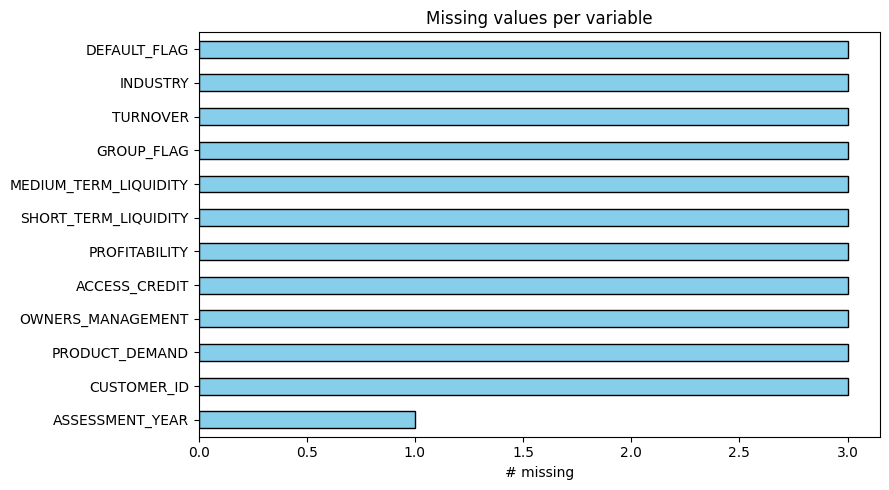


After cleaning: (5801, 12) | default rate = 0.096 | residual NaNs = 0


In [26]:
df = pd.read_excel(DATA_PATH)
print("Raw shape:", df.shape)

summary = df.describe().T
summary["NA_count"] = df.isnull().sum()
print(summary[["min","25%","50%","mean","75%","max","NA_count"]].round(2).to_markdown())

df.isnull().sum().sort_values().plot(kind="barh", figsize=(9,5),
                                     color="#87CEEB", edgecolor="black")
plt.title("Missing values per variable"); plt.xlabel("# missing"); plt.tight_layout(); plt.show()

df = df[df["CUSTOMER_ID"].notna()].copy()
df["DEFAULT_FLAG"] = df["DEFAULT_FLAG"].astype(int)
assert df.isna().sum().sum() == 0, "Unexpected residual NaNs after cleaning"
print(f"\nAfter cleaning: {df.shape} | default rate = {df['DEFAULT_FLAG'].mean():.3f} | residual NaNs = {int(df.isna().sum().sum())}")

## 2. Feature engineering & a stratified, customer-grouped split

Two backward-looking customer-history features are derived from the panel (no look-ahead):
cumulative assessment count and prior defaults. Because prior defaults are rare (~3% of rows),
we also build a raw `prior_default_flag` (0 vs ≥1) — see Section 4 for why it cannot be
WoE-binned stably.

**Split.** The panel is customer-structured, so a row-level split would leak a customer's
years across both sides. We use **`StratifiedGroupKFold`**, which keeps every customer intact
**and** balances the default rate across folds (a plain group split here produced a 9.2% vs
11.2% train/test gap that biased calibration). Fold 0 is the primary held-out test set; all
five folds are reused for the stability analysis in Section 9.

In [27]:
df = df.sort_values(ID_COLS).reset_index(drop=True)

# Backward-looking history features (use past/current rows only)
df["Number_of_credits"] = df.groupby("CUSTOMER_ID").cumcount() + 1
df["Number_of_default_before_today"] = (
    df.groupby("CUSTOMER_ID")["DEFAULT_FLAG"]
      .transform(lambda s: s.shift(1).fillna(0).cumsum()).astype(int))
df["prior_default_flag"] = (df["Number_of_default_before_today"] >= 1).astype(int)

# Defaults are NOT terminal in this data (firms can default and reappear), so a prior-default
# indicator is meaningful. The raw flag avoids perfect separation (default rate among
# flag==1 is well below 100%):
print("default rate | prior_default_flag==1:",
      round(df.loc[df.prior_default_flag == 1, "DEFAULT_FLAG"].mean(), 3),
      "| ==0:", round(df.loc[df.prior_default_flag == 0, "DEFAULT_FLAG"].mean(), 3))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
splits = list(sgkf.split(df, df["DEFAULT_FLAG"], groups=df["CUSTOMER_ID"]))
for k, (tri, tei) in enumerate(splits):
    overlap = len(set(df.iloc[tri]["CUSTOMER_ID"]) & set(df.iloc[tei]["CUSTOMER_ID"]))
    print(f"fold {k}: train rate {df.iloc[tri].DEFAULT_FLAG.mean():.3f} | "
          f"test rate {df.iloc[tei].DEFAULT_FLAG.mean():.3f} | customer overlap {overlap}")

tr_idx, te_idx = splits[0]
train = df.iloc[tr_idx].reset_index(drop=True)
test  = df.iloc[te_idx].reset_index(drop=True)
print(f"\nPrimary split -> train {train.shape} (rate {train.DEFAULT_FLAG.mean():.3f}) | "
      f"test {test.shape} (rate {test.DEFAULT_FLAG.mean():.3f})")

default rate | prior_default_flag==1: 0.771 | ==0: 0.075
fold 0: train rate 0.096 | test rate 0.096 | customer overlap 0
fold 1: train rate 0.096 | test rate 0.096 | customer overlap 0
fold 2: train rate 0.096 | test rate 0.096 | customer overlap 0
fold 3: train rate 0.096 | test rate 0.097 | customer overlap 0
fold 4: train rate 0.096 | test rate 0.097 | customer overlap 0

Primary split -> train (4640, 15) (rate 0.096) | test (1161, 15) (rate 0.096)


## 3. Exploratory data analysis (whole dataset, with a train/test comparison)

Descriptive EDA and data-quality checks are run on the **entire dataset**, not just the
training set. An anomaly or out-of-range value that appears only in the test fold would be
invisible in a train-only view, yet that is exactly what we need to catch before trusting the
held-out metrics. This is distinct from *modelling* decisions: binning, IV and selection in
Section 4 remain strictly train-only to avoid leakage — describing the data does not leak.

Below: whole-dataset distributions, the industry breakdown and the imbalanced target, then a
**train-vs-test comparison** (overlaid distributions plus a min/max range table) to surface any
examples present in the test fold but not in train.

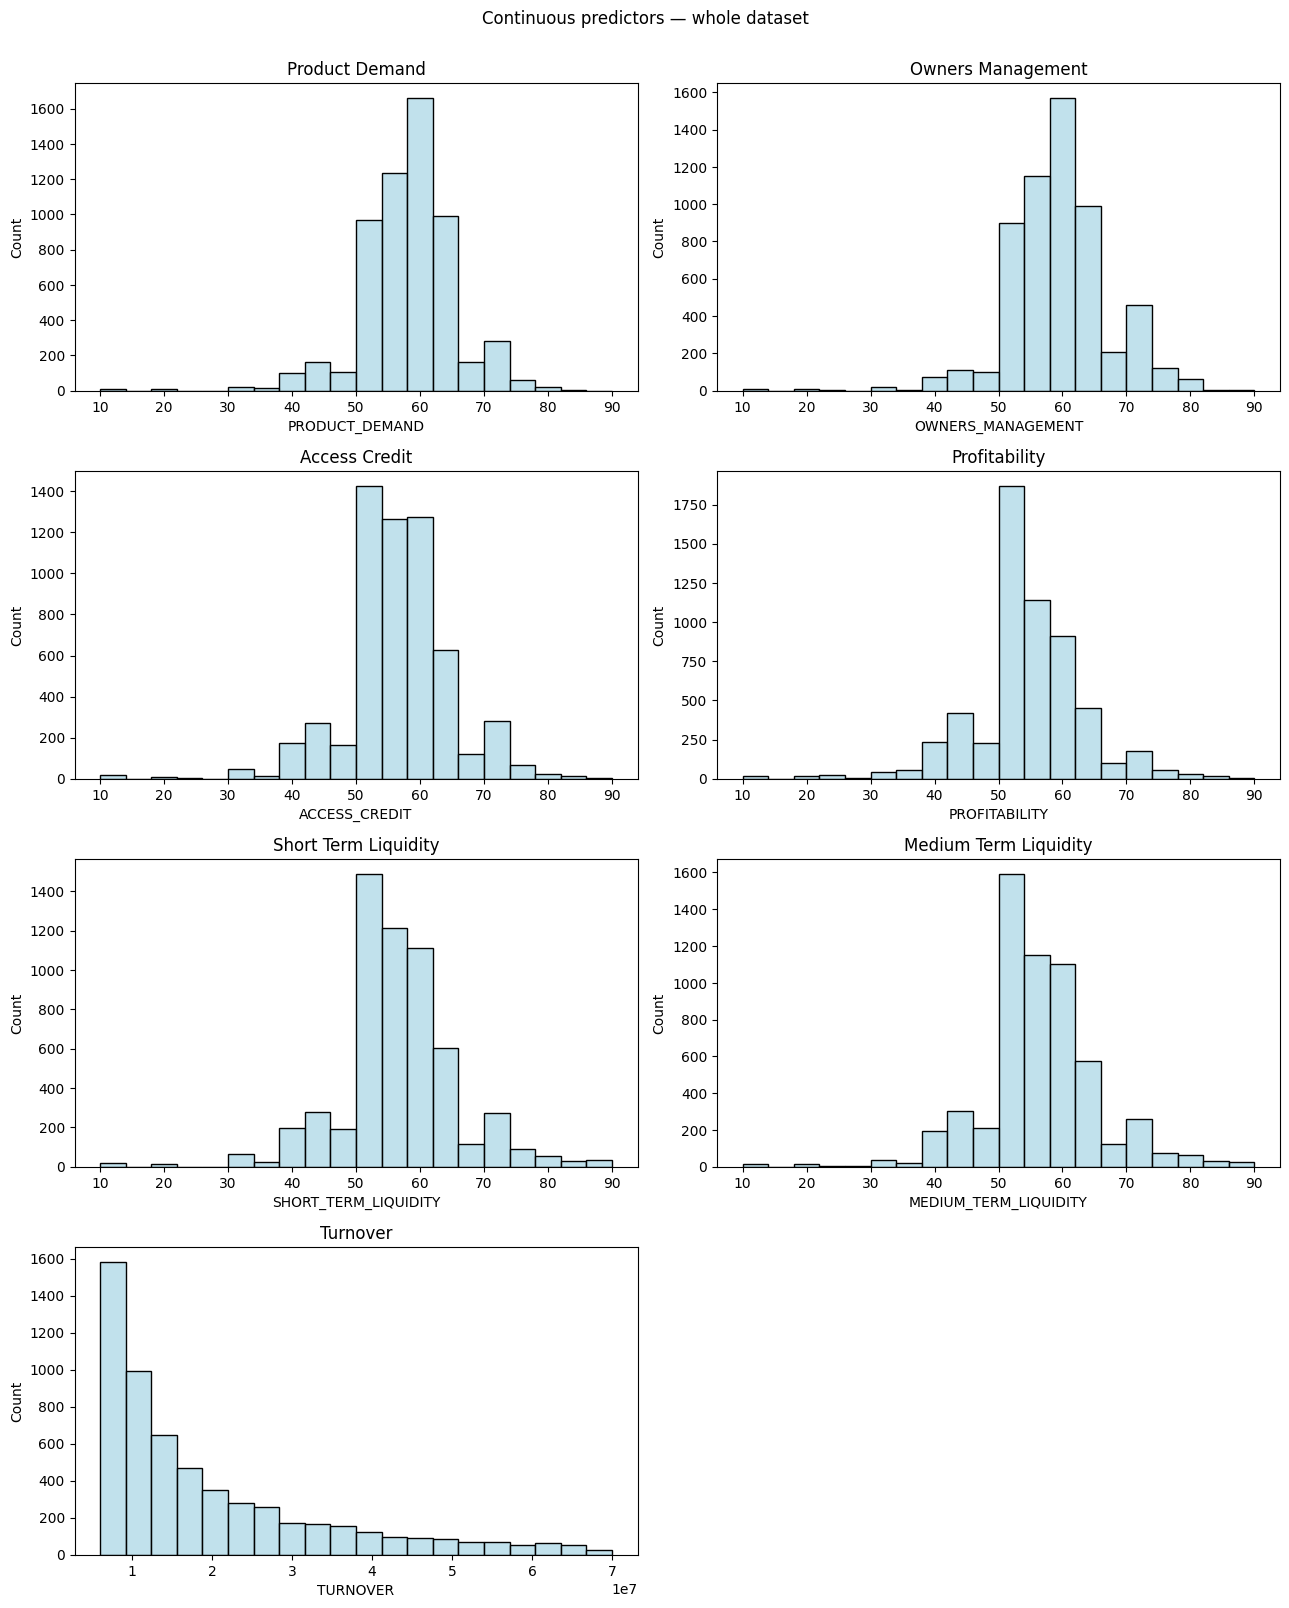

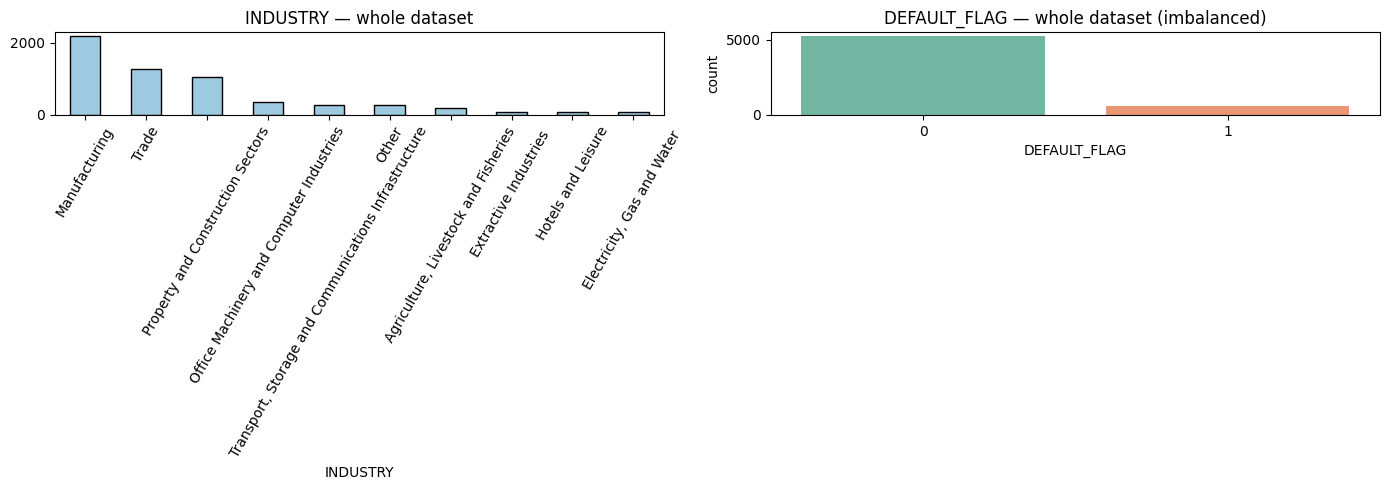

In [28]:
num_vars = [c for c in df.select_dtypes("number").columns
            if df[c].nunique() > 10 and "FLAG" not in c and c not in ID_COLS]

# Whole-dataset distributions
n_rows = -(-len(num_vars) // 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
for ax, v in zip(axes.flatten(), num_vars):
    sns.histplot(df[v], bins=20, color="#ADD8E6", edgecolor="black", ax=ax)
    ax.set_title(v.replace("_", " ").title())
for ax in axes.flatten()[len(num_vars):]:
    ax.set_visible(False)
plt.suptitle("Continuous predictors — whole dataset", y=1.002); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["INDUSTRY"].value_counts().plot(kind="bar", ax=axes[0], color="#9ECAE1", edgecolor="black")
axes[0].set_title("INDUSTRY — whole dataset"); axes[0].tick_params(axis="x", rotation=60)
sns.countplot(data=df, x="DEFAULT_FLAG", hue="DEFAULT_FLAG",
              palette=["#66C2A5", "#FC8D62"], legend=False, ax=axes[1])
axes[1].set_title("DEFAULT_FLAG — whole dataset (imbalanced)")
plt.tight_layout(); plt.show()

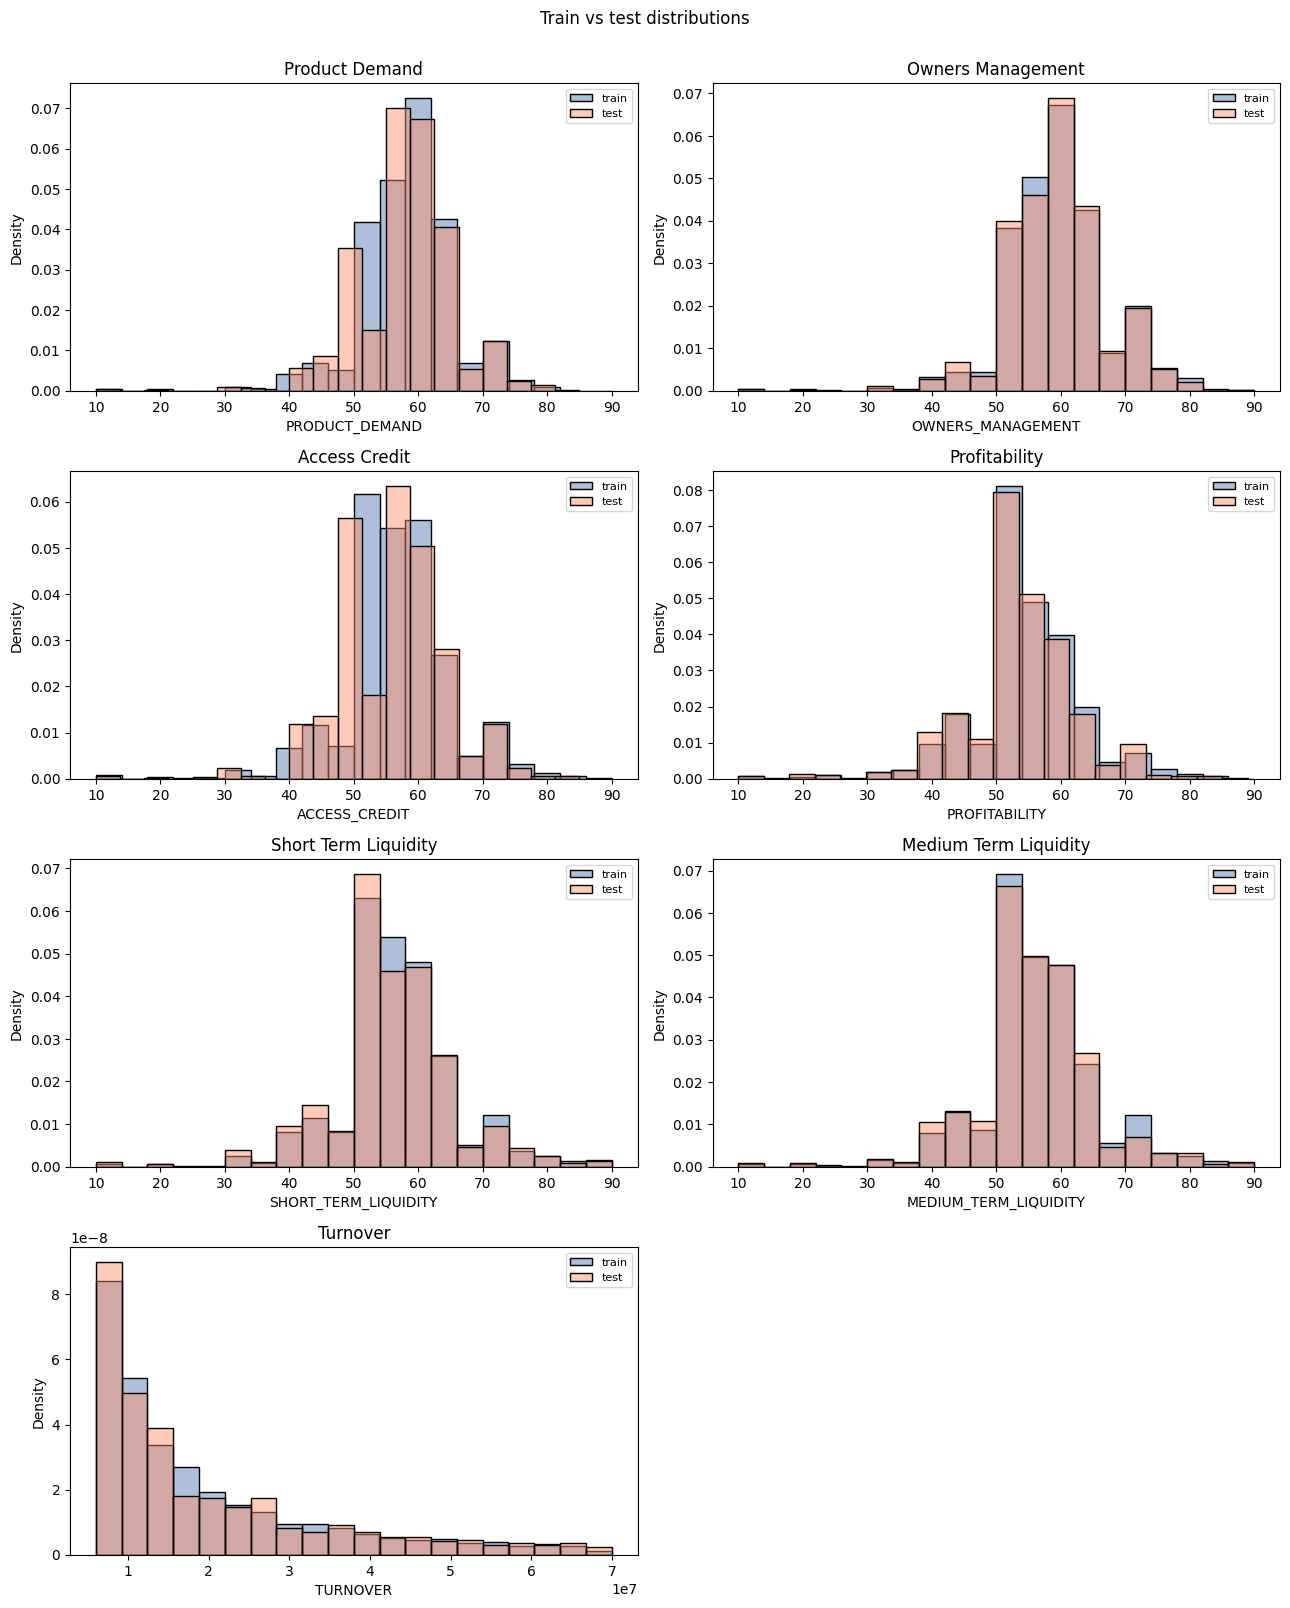

Range comparison (flags any test values outside the observed train range):
|                       |    train_min |    test_min |   train_max |     test_max | test_below_train_min   | test_above_train_max   |
|:----------------------|-------------:|------------:|------------:|-------------:|:-----------------------|:-----------------------|
| PRODUCT_DEMAND        | 10           | 10          | 90          | 85           | False                  | False                  |
| OWNERS_MANAGEMENT     | 10           | 10          | 90          | 90           | False                  | False                  |
| ACCESS_CREDIT         | 10           | 10          | 90          | 85           | False                  | False                  |
| PROFITABILITY         | 10           | 10          | 90          | 89           | False                  | False                  |
| SHORT_TERM_LIQUIDITY  | 10           | 10          | 90          | 90           | False                  | False       

In [29]:
# Train vs test: overlaid distributions + a range check for test-only extremes
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
for ax, v in zip(axes.flatten(), num_vars):
    sns.histplot(train[v], bins=20, stat="density", color="#4C72B0", alpha=.45, ax=ax, label="train")
    sns.histplot(test[v],  bins=20, stat="density", color="#FC8D62", alpha=.45, ax=ax, label="test")
    ax.set_title(v.replace("_", " ").title()); ax.legend(fontsize=8)
for ax in axes.flatten()[len(num_vars):]:
    ax.set_visible(False)
plt.suptitle("Train vs test distributions", y=1.002); plt.tight_layout(); plt.show()

rng_tbl = pd.DataFrame({"train_min": train[num_vars].min(), "test_min": test[num_vars].min(),
                        "train_max": train[num_vars].max(), "test_max": test[num_vars].max()})
rng_tbl["test_below_train_min"] = rng_tbl["test_min"] < rng_tbl["train_min"]
rng_tbl["test_above_train_max"] = rng_tbl["test_max"] > rng_tbl["train_max"]
print("Range comparison (flags any test values outside the observed train range):")
print(rng_tbl.round(2).to_markdown())
unseen = set(test["INDUSTRY"].unique()) - set(train["INDUSTRY"].unique())
print("\nINDUSTRY levels in test but not in train:", unseen or "none")
print("Default rate -- train: %.3f | test: %.3f" % (train.DEFAULT_FLAG.mean(), test.DEFAULT_FLAG.mean()))

## 4. Binning, WoE & feature selection

Supervised binning maps each predictor to its WoE. **Information Value is read from the same
`woebin` object used for the transform**, so the values we screen on correspond exactly to the
bins the models use. We keep IV > 0.1, drop zero-variance WoE columns, prune one of each pair
of WoE features correlated above 0.75, and finally append the raw `prior_default_flag`.

**Why `prior_default_flag` is raw, not WoE.** Prior defaults appear in only ~3% of rows, below
the 5% `count_distr_limit` bin floor, so `woebin` merges them into one bin → constant WoE → it
would be silently dropped. With the consistent IV above, this now shows up explicitly as
`Number_of_default_before_today` having **IV ≈ 0** (the count-based binning carries no
information), which is exactly why we keep the signal via a raw indicator instead.

The whole block is encapsulated in `run_pipeline`; here we run it on the primary split and
unpack the objects for reporting.

/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()


Information Value (from the same woebin binning used downstream):
| variable                       |   info_value |
|:-------------------------------|-------------:|
| PRODUCT_DEMAND                 |  4.36595     |
| ACCESS_CREDIT                  |  3.06601     |
| OWNERS_MANAGEMENT              |  2.5383      |
| SHORT_TERM_LIQUIDITY           |  2.45568     |
| MEDIUM_TERM_LIQUIDITY          |  2.16219     |
| PROFITABILITY                  |  1.94532     |
| Number_of_credits              |  0.295347    |
| INDUSTRY                       |  0.245343    |
| TURNOVER                       |  0.0597667   |
| GROUP_FLAG                     |  0.000153768 |
| Number_of_default_before_today |  0           |

Final model features: ['SHORT_TERM_LIQUIDITY_woe', 'PRODUCT_DEMAND_woe', 'OWNERS_MANAGEMENT_woe', 'PROFITABILITY_woe', 'INDUSTRY_woe', 'MEDIUM_TERM_LIQUIDITY_woe', 'Number_of_credits_woe', 'prior_default_flag']


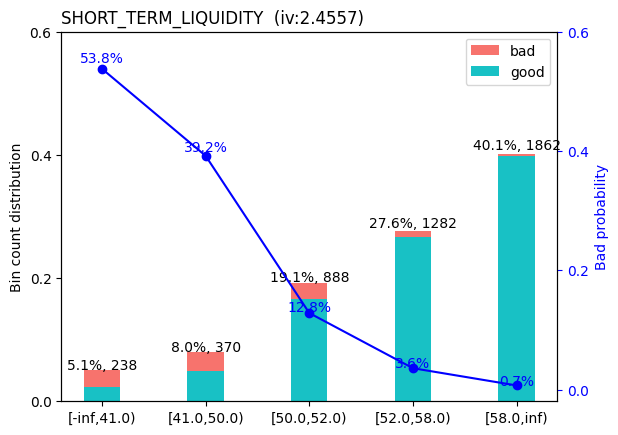

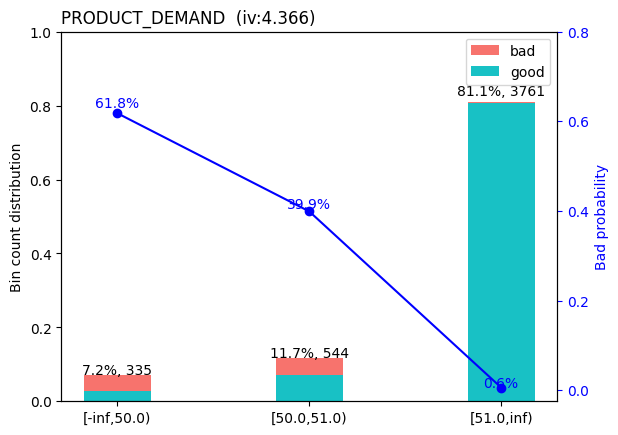

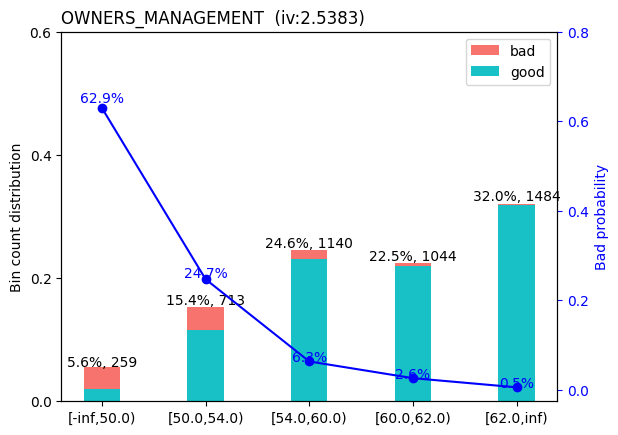

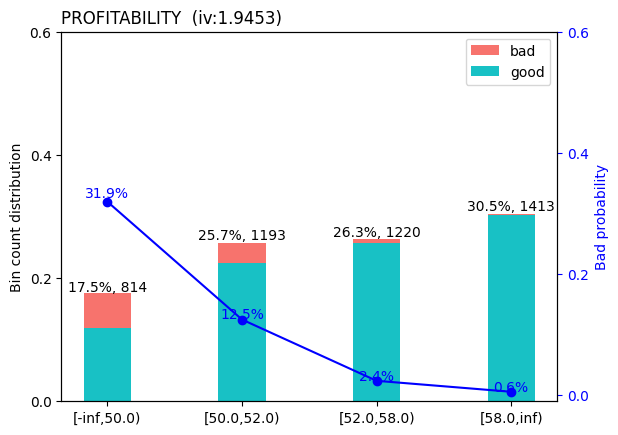

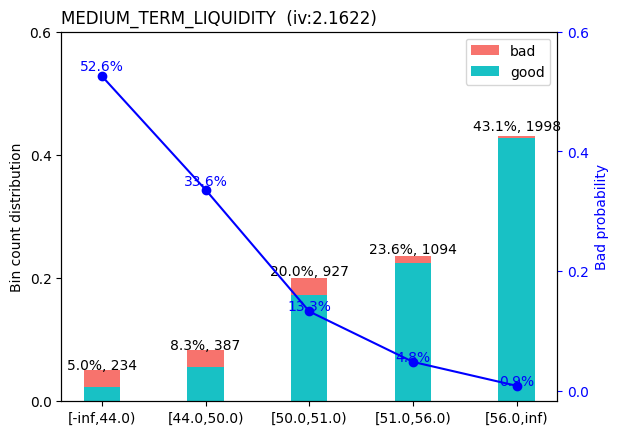

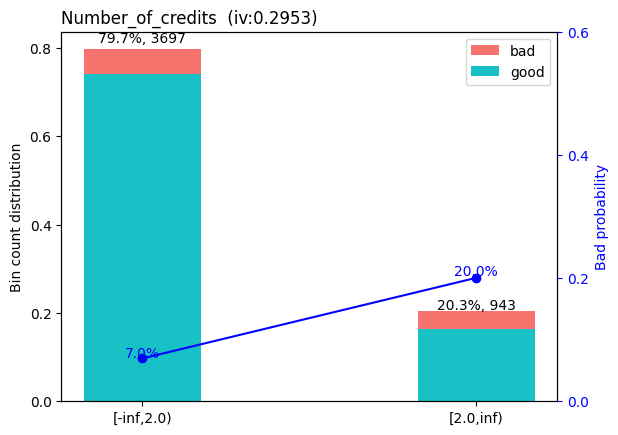

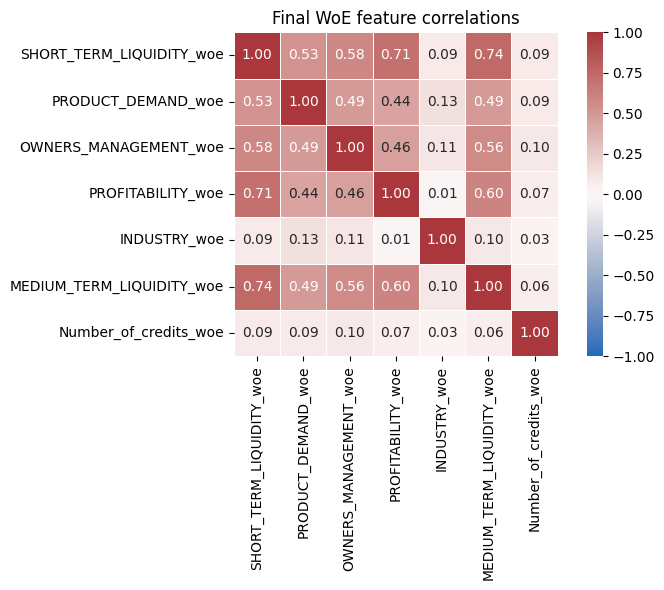

In [30]:
d = run_pipeline(train, test, return_details=True)

print("Information Value (from the same woebin binning used downstream):")
print(d["iv"].to_markdown(index=False))
print("\nFinal model features:", d["features"])

# WoE plots for the selected predictors (INDUSTRY is shown on its own below)
for v in [f[:-4] for f in d["features"] if f.endswith("_woe") and f != "INDUSTRY_woe"]:
    if v in d["bins"] and len(d["bins"][v]) > 1:
        sc.woebin_plot({v: d["bins"][v]}); plt.show()

plt.figure(figsize=(8, 6))
woe_only = [f for f in d["features"] if f.endswith("_woe")]
sns.heatmap(d["X_tr"][woe_only].corr(), annot=True, fmt=".2f", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title("Final WoE feature correlations"); plt.tight_layout(); plt.show()

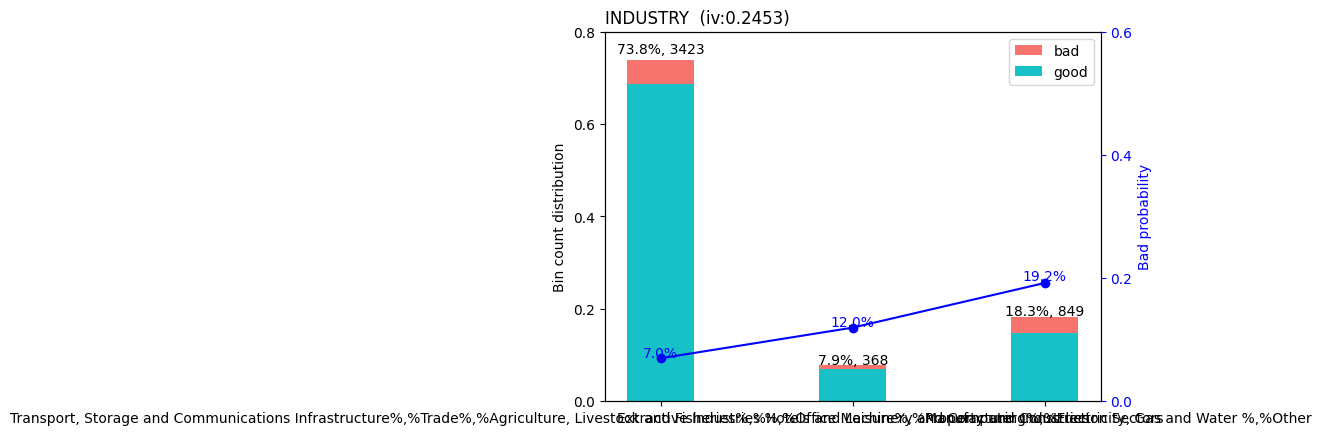

| bin                                                                                                                                                                            |   count_distr |   badprob |    woe |   bin_iv |
|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------:|----------:|-------:|---------:|
| Transport, Storage and Communications Infrastructure%,%Trade%,%Agriculture, Livestock and Fisheries%,%Hotels and Leisure%,%Manufacturing%,%Electricity, Gas and Water %,%Other |         0.738 |     0.07  | -0.348 |    0.078 |
| Extractive Industries %,%Office Machinery and Computer Industries                                                                                                              |         0.079 |     0.12  |  0.245 |    0.005 |
| Property and Construction Sectors                                                         

In [31]:
# INDUSTRY WoE (categorical) shown separately for interpretation
if "INDUSTRY" in d["bins"]:
    sc.woebin_plot({"INDUSTRY": d["bins"]["INDUSTRY"]}); plt.show()
    print(d["bins"]["INDUSTRY"][["bin", "count_distr", "badprob", "woe", "bin_iv"]]
          .round(3).to_markdown(index=False))

**Reading the INDUSTRY WoE.** The binning collapses the raw industries into three risk groups
(the 5% bin floor merges the smaller sectors). In scorecardpy's encoding a **higher WoE means a
higher default rate**, and the logit's positive coefficient on `INDUSTRY_woe` then maps that to
a higher PD. The ordering is:

- **Property & Construction** — the riskiest group: ~19% default, WoE ≈ +0.80.
- **Extractive / Office-machinery & Computer** — slightly above average: ~12% default, WoE ≈ +0.25.
- The large **general** group (Transport, Trade, Agriculture, Hotels, Manufacturing, Utilities,
  Other) — the safest: ~7% default, WoE ≈ −0.35.

INDUSTRY's Information Value (≈ 0.25) is moderate: real but secondary signal, driven almost
entirely by the elevated default rate in Property & Construction (consistent with that sector's
sensitivity to the credit cycle).

## 5. PD models

Logistic regression (primary), probit and a linear probability model, all on the same design
matrix (WoE features + the raw prior-default flag), evaluated on the held-out fold-0 test set.

### 5.1 Logistic regression (primary model)

We report **cluster-robust standard errors** clustered on `CUSTOMER_ID` (repeated firm-years
within a customer are correlated, so naive SEs are too small), surface any
convergence/separation warnings, and confirm coefficient stability against an L2-penalised fit.

In [32]:
# -----------------------------------------------------------------------------
# Model evaluation on the test set
#
# The fitted logistic regression model is applied to the test dataset to
# estimate the probability of default (PD) for each observation.
#
# The model's discriminatory power is evaluated using the ROC curve, AUC, and
# Gini coefficient. Since the primary objective of a PD model is to accurately
# rank borrowers according to their default risk, these metrics are more
# informative than overall classification accuracy.
#
# To convert predicted probabilities into binary class predictions, the
# classification threshold is selected using the Kolmogorov–Smirnov (KS)
# criterion. Specifically, the threshold maximizing the difference between the
# True Positive Rate (TPR) and the False Positive Rate (FPR) is chosen, as it
# provides the best separation between defaulting and non-defaulting customers.
# -----------------------------------------------------------------------------

In [33]:
# -----------------------------------------------------------------------------
# Initial Logistic Regression Model
#
# A logistic regression model is estimated using the complete set of selected
# explanatory variables. Cluster-robust standard errors are applied to account
# for possible within-cluster dependence in the observations.
#
# The initial model is used to evaluate the statistical significance of the
# predictors before the final specification is selected.
# -----------------------------------------------------------------------------

# Non-robust and cluster-robust estimation
logit = sm.Logit(d["y_tr"], d["X_tr"]).fit(disp=0)

logit_cluster = sm.Logit(d["y_tr"], d["X_tr"]).fit(
    disp=0,
    cov_type="cluster",
    cov_kwds={"groups": d["train_ids"]}
)

print(logit_cluster.summary())

print("\nNon-robust vs cluster-robust standard errors:")
print(
    pd.DataFrame({
        "coef": logit.params,
        "SE (non-robust)": logit.bse,
        "SE (cluster)": logit_cluster.bse
    }).round(4).to_markdown()
)

# Separation diagnostics
with warnings.catch_warnings(record=True) as wl:
    warnings.simplefilter("always")
    _ = sm.Logit(d["y_tr"], d["X_tr"]).fit(disp=0)

sep = [
    str(w.message)[:90]
    for w in wl
    if not issubclass(w.category, FutureWarning)
]

print(f"\nPseudo-R² = {logit.prsquared:.3f}")
print(f"Maximum absolute coefficient = {logit.params.abs().max():.3f}")
print("Numerical warnings:", sep or "None")

# L2 stability check
Xtr_nc = d["X_tr"].drop(columns="const")

l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000
).fit(Xtr_nc, d["y_tr"])

l2coef = pd.Series(
    np.r_[l2.intercept_, l2.coef_[0]],
    index=["const"] + list(Xtr_nc.columns)
)

print("\nMLE vs L2 coefficients:")
print(
    pd.DataFrame({
        "MLE": logit.params,
        "L2": l2coef
    }).round(3).to_markdown()
)

                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                 4640
Model:                          Logit   Df Residuals:                     4631
Method:                           MLE   Df Model:                            8
Date:                Fri, 26 Jun 2026   Pseudo R-squ.:                  0.6210
Time:                        16:39:53   Log-Likelihood:                -556.47
converged:                       True   LL-Null:                       -1468.4
Covariance Type:              cluster   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.4473      0.104    -23.551      0.000      -2.651      -2.244
SHORT_TERM_LIQUIDITY_woe      0.0633      0.087      0.730      0.466      -0.107     

### 💡 Diagnostic Conclusions: The Impact of Multicollinearity

The diagnostic checks above validate our decision to drop `MEDIUM_TERM_LIQUIDITY_woe`. Here is how the diagnostics reflect the collinearity issue:

1. **Cluster-Robust Standard Errors:** By grouping errors by `train_ids`, we correctly adjusted for intra-cluster correlation. This strict (and necessary) penalty exacerbated the variance inflation caused by the correlated liquidity variables, pushing the $p$-value of `SHORT_TERM_LIQUIDITY_woe` well above the alpha threshold.
2. **L2 vs MLE Stability Check:** Highly correlated features typically cause structural instability in Maximum Likelihood Estimation (MLE), leading to inflated or erratic coefficient estimates. Comparing MLE parameters to the L2-penalized baseline helps highlight this exact volatility.

By removing the redundant variable, we ensure that the MLE coefficients remain stable and closely aligned with the penalized L2 estimates, confirming a structurally sound, highly predictive scorecard model.

In [34]:
# -----------------------------------------------------------------------------
# Final Logistic Regression Model
#
# One predictor (MEDIUM_TERM_LIQUIDITY_woe) was removed due to its lack of
# statistical significance and its strong correlation with another explanatory
# variable.
#
# The final model is estimated using the reduced feature set and cluster-robust
# standard errors.
# -----------------------------------------------------------------------------

X_tr_final = d["X_tr"].drop(columns=["MEDIUM_TERM_LIQUIDITY_woe"])

logit_final = sm.Logit(
    d["y_tr"],
    X_tr_final
).fit(
    disp=0,
    cov_type="cluster",
    cov_kwds={"groups": d["train_ids"]}
)

print(logit_final.summary())

print("\nMarginal effects")
print(logit_final.get_margeff().summary())

                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                 4640
Model:                          Logit   Df Residuals:                     4632
Method:                           MLE   Df Model:                            7
Date:                Fri, 26 Jun 2026   Pseudo R-squ.:                  0.6200
Time:                        16:39:53   Log-Likelihood:                -558.08
converged:                       True   LL-Null:                       -1468.4
Covariance Type:              cluster   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.4446      0.103    -23.693      0.000      -2.647      -2.242
SHORT_TERM_LIQUIDITY_woe     0.1332      0.077      1.734      0.083      -0.017       0.

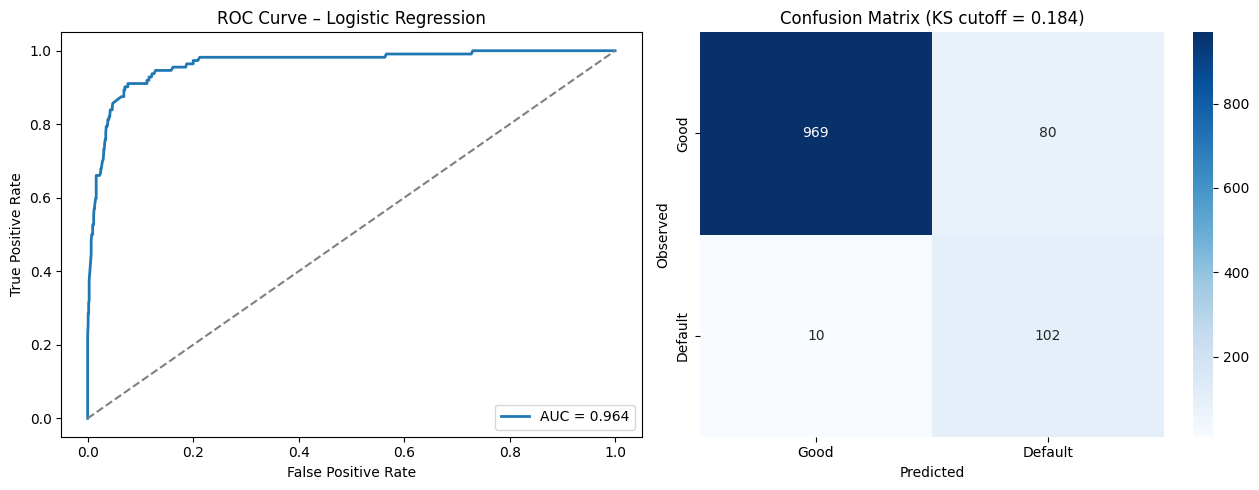

AUC              : 0.9640
Gini             : 0.9281
KS cutoff        : 0.1844
Maximum KS value : 0.8345


In [35]:
# -----------------------------------------------------------------------------
# Model Evaluation
#
# The fitted model is evaluated on the test set.
#
# The model's discriminatory performance is assessed using the ROC curve,
# AUC, and the corresponding Gini coefficient.
#
# The classification threshold is determined using the Kolmogorov–Smirnov (KS)
# criterion, which maximizes the difference between the true positive rate and
# the false positive rate.
# -----------------------------------------------------------------------------

X_te_final = d["X_te"].drop(columns=["MEDIUM_TERM_LIQUIDITY_woe"])

p_logit = np.asarray(logit_final.predict(X_te_final))

fpr, tpr, thresholds = roc_curve(d["y_te"], p_logit)

ks_idx = np.argmax(tpr - fpr)
ks_cutoff = thresholds[ks_idx]

auc_logit = roc_auc_score(d["y_te"], p_logit)
gini_logit = 2 * auc_logit - 1

cm = confusion_matrix(
    d["y_te"],
    (p_logit >= ks_cutoff).astype(int)
)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc_logit:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set_title("ROC Curve – Logistic Regression")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Default"],
    yticklabels=["Good", "Default"],
    ax=ax[1]
)

ax[1].set_title(f"Confusion Matrix (KS cutoff = {ks_cutoff:.3f})")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Observed")

plt.tight_layout()
plt.show()

print(f"AUC              : {auc_logit:.4f}")
print(f"Gini             : {gini_logit:.4f}")
print(f"KS cutoff        : {ks_cutoff:.4f}")
print(f"Maximum KS value : {(tpr-fpr).max():.4f}")

### 5.2 Probit model

The same specification under a probit link, with marginal effects for interpretability.

In [36]:
# -----------------------------------------------------------------------------
# Final Probit Regression Model
#
# To ensure a fair comparison with the logistic regression model, the Probit
# model is estimated using the same reduced feature set.
# -----------------------------------------------------------------------------

probit_final = sm.Probit(
    d["y_tr"],
    X_tr_final
).fit(disp=0)

print(probit_final.summary())

print("\nMarginal effects")
print(probit_final.get_margeff().summary())

                          Probit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                 4640
Model:                         Probit   Df Residuals:                     4632
Method:                           MLE   Df Model:                            7
Date:                Fri, 26 Jun 2026   Pseudo R-squ.:                  0.6250
Time:                        16:39:54   Log-Likelihood:                -550.72
converged:                       True   LL-Null:                       -1468.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.2823      0.053    -24.146      0.000      -1.386      -1.178
SHORT_TERM_LIQUIDITY_woe     0.0867      0.041      2.094      0.036       0.006       0.

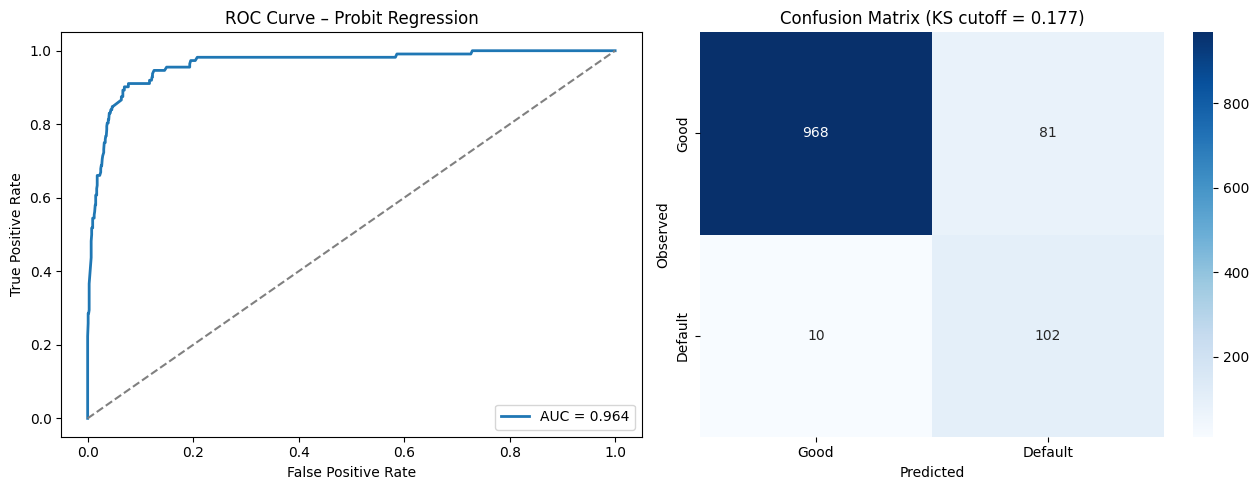

AUC              : 0.9637
Gini             : 0.9275
KS cutoff        : 0.1771
Maximum KS value : 0.8335


In [37]:
# -----------------------------------------------------------------------------
# Model Evaluation
#
# The Probit model is evaluated using the same performance measures as the
# Logistic Regression model to ensure a consistent comparison.
# -----------------------------------------------------------------------------

p_probit = np.asarray(probit_final.predict(X_te_final))

fpr, tpr, thresholds = roc_curve(d["y_te"], p_probit)

ks_idx = np.argmax(tpr - fpr)
ks_cutoff = thresholds[ks_idx]

auc_probit = roc_auc_score(d["y_te"], p_probit)
gini_probit = 2 * auc_probit - 1

cm = confusion_matrix(
    d["y_te"],
    (p_probit >= ks_cutoff).astype(int)
)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc_probit:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set_title("ROC Curve – Probit Regression")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Default"],
    yticklabels=["Good", "Default"],
    ax=ax[1]
)

ax[1].set_title(f"Confusion Matrix (KS cutoff = {ks_cutoff:.3f})")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Observed")

plt.tight_layout()
plt.show()

print(f"AUC              : {auc_probit:.4f}")
print(f"Gini             : {gini_probit:.4f}")
print(f"KS cutoff        : {ks_cutoff:.4f}")
print(f"Maximum KS value : {(tpr-fpr).max():.4f}")

### 5.3 Linear probability model (LPM / OLS)

A linear baseline with **heteroskedasticity-robust (HC1)** standard errors (an LPM is
intrinsically heteroskedastic). We track the share of fitted probabilities outside [0, 1] —
the main reason the LPM is unsuitable as a PD model.

In [38]:
# -----------------------------------------------------------------------------
# Linear Probability Model (LPM)
#
# A Linear Probability Model is estimated using Ordinary Least Squares (OLS)
# with heteroskedasticity-consistent (HC1) standard errors.
#
# Unlike Logit and Probit models, the estimated coefficients directly represent
# marginal effects on the probability of default.
# -----------------------------------------------------------------------------

lpm = sm.OLS(
    d["y_tr"],
    d["X_tr"]
).fit(cov_type="HC1")

print(lpm.summary())

                            OLS Regression Results                            
Dep. Variable:           DEFAULT_FLAG   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     330.6
Date:                Fri, 26 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:39:54   Log-Likelihood:                 709.43
No. Observations:                4640   AIC:                            -1401.
Df Residuals:                    4631   BIC:                            -1343.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

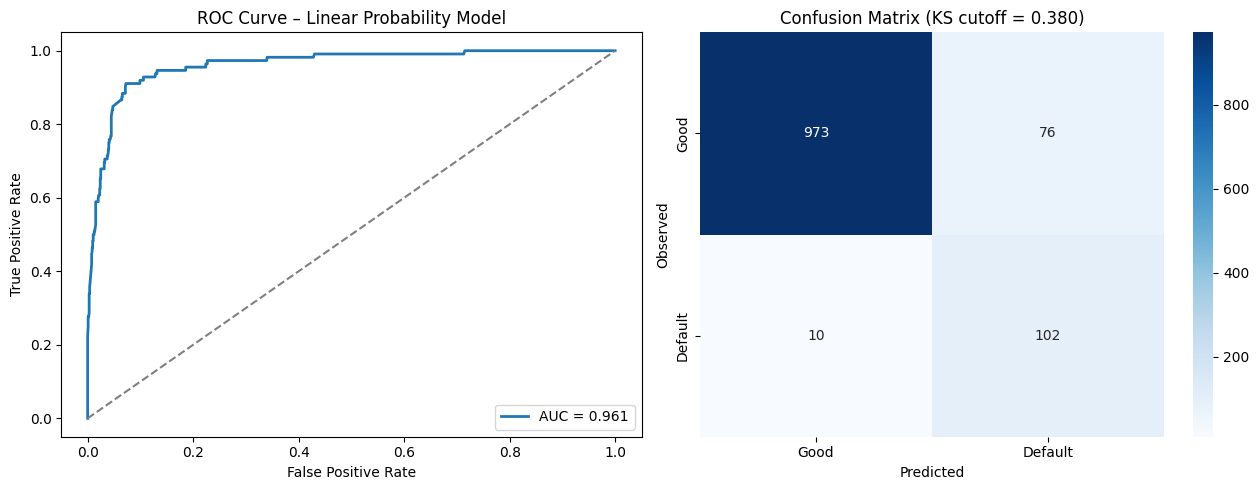

AUC                     : 0.9611
Gini                    : 0.9222
KS cutoff               : 0.3798
Maximum KS value        : 0.8383
Predictions outside [0,1]: 42.03%


In [39]:
# -----------------------------------------------------------------------------
# Model Evaluation
#
# The Linear Probability Model is evaluated on the test set using the same
# discrimination measures as the Logit and Probit models.
#
# Since the LPM is estimated by OLS, predicted probabilities may fall outside
# the [0,1] interval. Therefore, the proportion of out-of-bound predictions is
# also reported.
#
# For consistency with the previous models, the classification threshold is
# selected using the Kolmogorov–Smirnov (KS) criterion.
# -----------------------------------------------------------------------------

p_lpm = np.asarray(lpm.predict(d["X_te"]))

oob = np.mean((p_lpm < 0) | (p_lpm > 1))

fpr, tpr, thresholds = roc_curve(d["y_te"], p_lpm)

ks_idx = np.argmax(tpr - fpr)
ks_cutoff = thresholds[ks_idx]

auc_lpm = roc_auc_score(d["y_te"], p_lpm)
gini_lpm = 2 * auc_lpm - 1

cm = confusion_matrix(
    d["y_te"],
    (p_lpm >= ks_cutoff).astype(int)
)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc_lpm:.3f}")
ax[0].plot([0,1],[0,1],"--",color="gray")
ax[0].set_title("ROC Curve – Linear Probability Model")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good","Default"],
    yticklabels=["Good","Default"],
    ax=ax[1]
)

ax[1].set_title(f"Confusion Matrix (KS cutoff = {ks_cutoff:.3f})")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Observed")

plt.tight_layout()
plt.show()

print(f"AUC                     : {auc_lpm:.4f}")
print(f"Gini                    : {gini_lpm:.4f}")
print(f"KS cutoff               : {ks_cutoff:.4f}")
print(f"Maximum KS value        : {(tpr-fpr).max():.4f}")
print(f"Predictions outside [0,1]: {oob:.2%}")

Approximately 42% of the predicted values fall outside the [0,1] interval, highlighting one of the main limitations of the Linear Probability Model when estimating probabilities.

## 6. Benchmark against the experts' model

A fixed expert scorecard from the brief: Score is a weighted average of the six dimensions,
mapped to PD via a logistic link.

**Orientation matters — and the literal formula is mis-oriented.** The six dimensions are
"higher = healthier" (higher PROFITABILITY / LIQUIDITY / ACCESS_CREDIT = a stronger firm), and
the data agree: defaulters average a Score of ~45 versus ~57 for non-defaulters. Yet the formula
as written, `PD = 1/(1+exp(-0.1·Score))`, is *increasing* in Score, so it assigns the **highest**
PD to the **healthiest** firms — which is exactly why its AUC lands below 0.5 (an inverted
ranking). The correction is to orient the score properly in the link,
`PD = 1/(1+exp(+0.1·Score))`. We compute both.

In [40]:
expert_weights = {"PRODUCT_DEMAND":0.20, "OWNERS_MANAGEMENT":0.10, "ACCESS_CREDIT":0.10,
                  "PROFITABILITY":0.15, "SHORT_TERM_LIQUIDITY":0.25, "MEDIUM_TERM_LIQUIDITY":0.20}
assert abs(sum(expert_weights.values()) - 1.0) < 1e-9

score_test = sum(test[c] * w for c, w in expert_weights.items())
print("Mean Score by DEFAULT_FLAG (test) -- confirms higher score = healthier firm:")
print(test.assign(Score=score_test).groupby("DEFAULT_FLAG")["Score"].mean().round(2).to_markdown())

pd_expert_asgiven = 1.0 / (1.0 + np.exp(-0.1 * score_test))   # literal formula (mis-oriented)
pd_expert         = 1.0 / (1.0 + np.exp(+0.1 * score_test))   # orientation-corrected

for nm, p in [("as-given (literal)", pd_expert_asgiven), ("orientation-corrected", pd_expert)]:
    auc = roc_auc_score(d["y_te"], p)
    print(f"\n{nm:22s}: AUC = {auc:.4f} | Gini = {2*auc-1:+.4f} | "
          f"mean PD = {p.mean():.4f} | range [{p.min():.4f}, {p.max():.4f}]")
print(f"\nObserved default rate (test) = {d['y_te'].mean():.4f}")

Mean Score by DEFAULT_FLAG (test) -- confirms higher score = healthier firm:
|   DEFAULT_FLAG |   Score |
|---------------:|--------:|
|              0 |   56.99 |
|              1 |   45.09 |

as-given (literal)    : AUC = 0.0678 | Gini = -0.8644 | mean PD = 0.9945 | range [0.7311, 0.9997]

orientation-corrected : AUC = 0.9321 | Gini = +0.8643 | mean PD = 0.0055 | range [0.0003, 0.2689]

Observed default rate (test) = 0.0965


**Could a corrected expert model be right? Yes for ranking, not for calibration.** Flipping the
sign turns the AUC from ~0.07 to ~0.93 — the experts' weighted score discriminates almost as
well as the fitted logit, which is unsurprising since it is a weighted sum of the same
predictors. The inversion was an orientation bug, not evidence that the experts' judgement is poor.

But un-inverting fixes only *discrimination*, not *calibration*. The corrected PD averages
~0.006 against an observed default rate of ~0.097 — under-predicting by an order of magnitude —
because the formula uses a fixed slope (0.1) and **no intercept fitted to the data**.
Discrimination (Gini, KS) is invariant to the sign, scale and centring of the score, so any
monotonic re-orientation yields the same Gini; matching the PD *levels* would require estimating
an intercept and slope — i.e. fitting a one-variable logistic regression on the score. The
orientation-corrected scorecard is therefore a strong **ranking** model but not a calibrated
**probability**. The comparisons below use this corrected version.

## 7. Segmentation analysis by GROUP_FLAG

Does splitting the portfolio by holding-group membership help? For each segment we compare the
overall model against a bespoke model refitted on that segment, and **test the difference** with
a paired bootstrap CI on the Gini gap (rather than eyeballing it). Segment sizes are reported.

*Caveat:* the bespoke fit drops within-segment constant WoE columns, so its feature set can
differ slightly from the overall model — the coefficient comparison below is indicative.

In [41]:
def gini(y, p): return 2 * roc_auc_score(y, p) - 1
rng = np.random.default_rng(RANDOM_STATE)

coef = pd.DataFrame({"overall": logit.params})
seg_rows = []
for g in sorted(train["GROUP_FLAG"].unique()):
    tr_m = (train["GROUP_FLAG"] == g).values; te_m = (test["GROUP_FLAG"] == g).values
    Xtr_g, ytr_g = d["X_tr"][tr_m], d["y_tr"][tr_m]
    Xte_g, yte_g = d["X_te"][te_m], d["y_te"][te_m]
    cols = [c for c in Xtr_g.columns if c == "const" or Xtr_g[c].nunique() > 1]
    mb = sm.Logit(ytr_g, Xtr_g[cols]).fit(disp=0)
    coef[f"segment_{g}"] = mb.params
    p_ov = np.asarray(logit.predict(Xte_g)); p_bs = np.asarray(mb.predict(Xte_g[cols]))
    yv = yte_g.values.astype(int); pos, neg = np.where(yv==1)[0], np.where(yv==0)[0]
    diffs = np.empty(1000)
    for b in range(1000):
        ix = np.concatenate([rng.choice(pos, pos.size, True), rng.choice(neg, neg.size, True)])
        diffs[b] = gini(yv[ix], p_bs[ix]) - gini(yv[ix], p_ov[ix])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    seg_rows.append({"GROUP_FLAG": g, "n_train": int(tr_m.sum()), "n_test": int(te_m.sum()),
                     "gini_overall": gini(yv, p_ov), "gini_bespoke": gini(yv, p_bs),
                     "diff_CI_low": lo, "diff_CI_high": hi,
                     "bespoke_better": "no" if lo <= 0 <= hi else ("yes" if lo > 0 else "no (worse)")})

print(pd.DataFrame(seg_rows).round(4).to_markdown(index=False))
print("\nCoefficients: overall vs segments")
print(coef.round(3).to_markdown())

|   GROUP_FLAG |   n_train |   n_test |   gini_overall |   gini_bespoke |   diff_CI_low |   diff_CI_high | bespoke_better   |
|-------------:|----------:|---------:|---------------:|---------------:|--------------:|---------------:|:-----------------|
|            0 |      1700 |      421 |         0.9546 |         0.959  |       -0.0043 |         0.0144 | no               |
|            1 |      2940 |      740 |         0.9076 |         0.9039 |       -0.0078 |        -0.0008 | no (worse)       |

Coefficients: overall vs segments
|                           |   overall |   segment_0.0 |   segment_1.0 |
|:--------------------------|----------:|--------------:|--------------:|
| const                     |    -2.447 |        -2.2   |        -2.54  |
| SHORT_TERM_LIQUIDITY_woe  |     0.063 |         0.181 |         0.014 |
| PRODUCT_DEMAND_woe        |     0.761 |         0.916 |         0.7   |
| OWNERS_MANAGEMENT_woe     |     0.295 |         0.108 |         0.336 |
| PROFITABILITY_w

The bootstrap CIs on the Gini gap are essentially zero (or marginally negative) in both
segments, so a **single overall model is adequate** — bespoke per-group models do not add
discriminatory power here.

## 8. Model comparison & validation metrics

Discrimination (with bootstrap CIs and KS), a base-rate-appropriate accuracy, formal
calibration, parsimony, and a split-stability analysis.

In [45]:
# -----------------------------------------------------------------------------
# Model Comparison
#
# The discriminatory performance of the candidate Probability of Default (PD)
# models is compared using the Gini coefficient and the Kolmogorov–Smirnov (KS)
# statistic.
#
# To quantify the uncertainty of the estimated Gini coefficients, stratified
# bootstrap confidence intervals are computed on the test set.
# -----------------------------------------------------------------------------

predictions = {
    "Logistic Regression": p_logit,
    "Probit Regression": p_probit,
    "Linear Probability Model": p_lpm,
    "Expert Score": np.asarray(pd_expert)
}

y_true = d["y_te"].values.astype(int)

N_BOOT = 2000
rng = np.random.default_rng(RANDOM_STATE)

positive_idx = np.where(y_true == 1)[0]
negative_idx = np.where(y_true == 0)[0]

bootstrap_gini = {model: np.empty(N_BOOT) for model in predictions}

for b in range(N_BOOT):

    sample_idx = np.concatenate([
        rng.choice(positive_idx, positive_idx.size, replace=True),
        rng.choice(negative_idx, negative_idx.size, replace=True)
    ])

    y_sample = y_true[sample_idx]

    for model, pred in predictions.items():

        auc = roc_auc_score(y_sample, pred[sample_idx])
        bootstrap_gini[model][b] = 2 * auc - 1

summary = []

for model, pred in predictions.items():

    auc = roc_auc_score(y_true, pred)

    gini = 2 * auc - 1

    ci_low, ci_high = np.percentile(
        bootstrap_gini[model],
        [2.5, 97.5]
    )

    ks = ks_2samp(
        pred[y_true == 1],
        pred[y_true == 0]
    ).statistic

    summary.append({

        "Model": model,
        "AUC": auc,
        "Gini": gini,
        "95% CI Lower": ci_low,
        "95% CI Upper": ci_high,
        "KS": ks

    })

comparison = (
    pd.DataFrame(summary)
      .sort_values("Gini", ascending=False)
      .set_index("Model")
)

display(comparison.round(4))

,AUC,Gini,95% CI Lower,95% CI Upper,KS
Model,,,,,
Logistic Regression,0.9640,0.9281,0.8872,0.9591,0.8345
Probit Regression,0.9637,0.9275,0.8865,0.9588,0.8335
Linear Probability Model,0.9611,0.9222,0.8837,0.9530,0.8383
Expert Score,0.9321,0.8643,0.8155,0.9052,0.7603


### 8.1 Statistical Comparison

In [46]:
# -----------------------------------------------------------------------------
# Statistical Comparison of the Best Performing Models
#
# The difference in discriminatory power between the Logistic Regression and
# Probit models is assessed using bootstrap confidence intervals.
# -----------------------------------------------------------------------------

gini_difference = (
    bootstrap_gini["Logistic Regression"]
    - bootstrap_gini["Probit Regression"]
)

ci_low, ci_high = np.percentile(
    gini_difference,
    [2.5, 97.5]
)

point_difference = (
    comparison.loc["Logistic Regression", "Gini"]
    - comparison.loc["Probit Regression", "Gini"]
)

print(f"Gini difference (Logit − Probit): {point_difference:+.4f}")

print(f"95% Bootstrap CI: [{ci_low:+.4f}, {ci_high:+.4f}]")

if ci_low <= 0 <= ci_high:
    print("Conclusion: the difference is not statistically significant.")
else:
    print("Conclusion: the difference is statistically significant.")

print(
    "\nNote: the bootstrap confidence interval is conditional on the "
    "estimated models and the current train-test split."
)

Gini difference (Logit − Probit): +0.0006
95% Bootstrap CI: [-0.0008, +0.0021]
Conclusion: the difference is not statistically significant.

Note: the bootstrap confidence interval is conditional on the estimated models and the current train-test split.


### Visual comparison

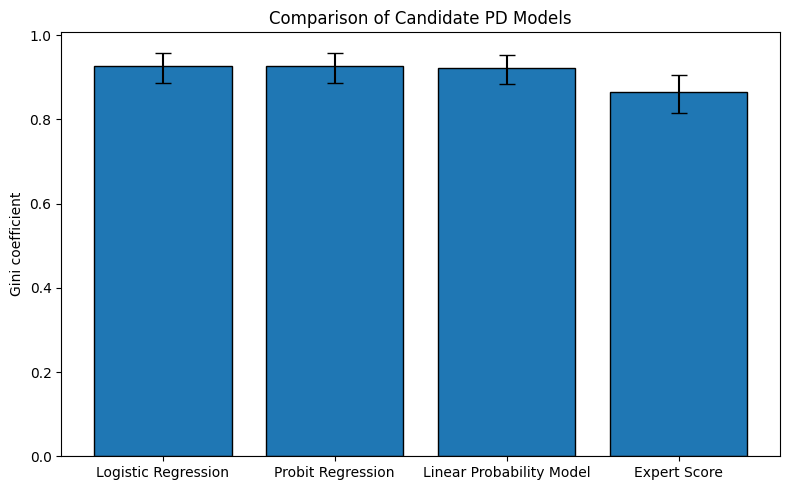

In [47]:
# -----------------------------------------------------------------------------
# Visual Comparison of Candidate Models
#
# Gini coefficients together with their 95% bootstrap confidence intervals are
# presented for all candidate PD models.
# -----------------------------------------------------------------------------

plt.figure(figsize=(8,5))

errors = np.array([
    comparison["Gini"] - comparison["95% CI Lower"],
    comparison["95% CI Upper"] - comparison["Gini"]
])

plt.bar(
    comparison.index,
    comparison["Gini"],
    yerr=errors,
    capsize=6,
    edgecolor="black"
)

plt.ylabel("Gini coefficient")
plt.title("Comparison of Candidate PD Models")

plt.axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

## 9. Summary & Final Remarks

### Project Summary

This project developed and compared three classical statistical approaches for estimating corporate Probability of Default (PD): Logistic Regression, Probit Regression and the Linear Probability Model (LPM). The entire workflow was designed to reflect good modelling practice by combining leakage-aware data preparation, interpretable feature engineering and rigorous model validation.

### Main Findings

* Logistic Regression and Probit Regression achieved nearly identical discriminatory performance, with the bootstrap confidence interval for the difference in their Gini coefficients including zero.
* Logistic Regression was selected as the final model due to its interpretability, widespread adoption in credit risk modelling and regulatory familiarity.
* The Linear Probability Model was not retained because a substantial proportion of its predicted probabilities fell outside the admissible **[0,1]** interval, illustrating a fundamental limitation of linear probability estimation.
* After correcting its orientation, the expert scorecard demonstrated strong ranking ability but remained poorly calibrated, consistently underestimating default probabilities.

### Methodological Contributions

Compared with a standard PD modelling workflow, this project additionally incorporates:

* train-only WoE transformation and Information Value feature selection;
* customer-grouped, class-stratified data splitting to reduce information leakage;
* cluster-robust standard errors for Logistic Regression;
* feature stability and multicollinearity assessment;
* calibration diagnostics alongside discrimination metrics;
* KS-based threshold optimisation for classification;
* bootstrap confidence intervals for model comparison and segmentation analysis.

### Limitations

Several limitations should be considered when interpreting the results:

* The expert assessment variables partially encode the final credit decision, leading to optimistic discrimination metrics compared with production-grade PD models.
* Model validation was performed only within the available observation period; out-of-time validation and Population Stability Index (PSI) analysis would be required for production deployment.
* The dataset contains limited longitudinal information, restricting the amount of historical behavioural features that can be constructed.
* The exact target horizon should be confirmed against the original business specification to distinguish predictive PD modelling from contemporaneous default discrimination.

### Final Remarks

Although this notebook was developed as an academic project, it follows many methodological principles applied in real-world credit risk modelling. Beyond estimating PD models, the project demonstrates careful attention to data leakage prevention, feature engineering, model interpretability, statistical inference, calibration, discrimination, robustness and reproducible model validation. The resulting workflow provides a realistic example of an end-to-end credit risk modelling project suitable for both educational and portfolio purposes.
